# Summarize Spatial GCM Results

This notebook provides compact summaries of the spatial GCM experiments.

In [4]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import os

# Import dgp function from spatial_gcm module
# Note: Make sure spatial_gcm.py is in the same directory or in your Python path
try:
    from spatial_gcm import dgp
except ImportError:
    # If import fails, try adding current directory to path
    import sys
    import os
    sys.path.insert(0, os.getcwd())
    from spatial_gcm import dgp

# Configuration
RESULTS_FILE = 'spatial_results/results.pkl'  # Change this to your results file

# Custom model labels (modify these to change how models appear in plots)
MODEL_LABELS = {
    'outcome_gcm': 'GCM',
    'outcome_gm': 'GM',
    'outcome_cm': 'CM'
}

# Colors for each model
MODEL_COLORS = {
    'outcome_gcm': '#1f77b4',  # blue
    'outcome_gm': '#ff7f0e',   # orange
    'outcome_cm': '#2ca02c'    # green
}

# Figure size for 1/4 column width (approximately 2 inches)
FIG_WIDTH = 2.2
FIG_HEIGHT = 2.2

# Save figures
save = False
save_folder = 'saved_figs'

In [5]:
# Load results
with open(RESULTS_FILE, 'rb') as f:
    data = pickle.load(f)

experiments = data['experiments']
config = data['config']

print(f"Loaded {len(experiments)} experiments")
print(f"Seed: {config.get('seed', 'N/A')}")

Loaded 10 experiments
Seed: 42


## 1. Example Data from DGP

Plot example a, x, and y values generated from the data generating process using the seed from the first experiment.

<>:18: SyntaxWarning: invalid escape sequence '\o'
<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:34: SyntaxWarning: invalid escape sequence '\o'
<>:35: SyntaxWarning: invalid escape sequence '\o'
<>:48: SyntaxWarning: invalid escape sequence '\o'
<>:49: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\o'
<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:34: SyntaxWarning: invalid escape sequence '\o'
<>:35: SyntaxWarning: invalid escape sequence '\o'
<>:48: SyntaxWarning: invalid escape sequence '\o'
<>:49: SyntaxWarning: invalid escape sequence '\o'
/var/folders/j0/9vd_fwqs4c98p2g1cwp861w4417dn9/T/ipykernel_55566/1785458558.py:18: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel(f'$\omega_1$', fontsize=8)
/var/folders/j0/9vd_fwqs4c98p2g1cwp861w4417dn9/T/ipykernel_55566/1785458558.py:19: SyntaxWarning: invalid escape sequence '\o'
  ax.set_ylabel(f'$\omega_2$', fontsize=8)
/var/folders/j0/9vd_fwqs4c98p2g1cwp861w4417dn9/T

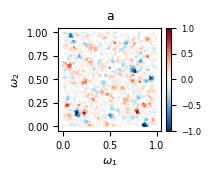

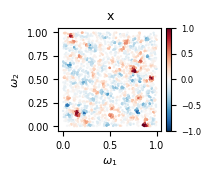

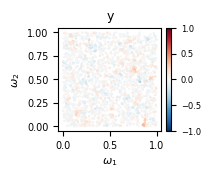

In [6]:
# Generate data using the seed from config (for first experiment)
from jax import random
seed = config.get('seed', 42)
key = random.key(seed)
key, subkey = random.split(key)

# Generate data for first experiment (use same n_samples as in config)
n_samples = config.get('n_samples', 2000)
loc, u, x, a, y, true_effect = dgp(n_samples, subkey)

# Create compact plots (1/4 column width)
fig, ax = plt.subplots(1, 1, figsize=(FIG_WIDTH, FIG_HEIGHT))

# Plot a
# Use color scale from -1 to 1
sc1 = ax.scatter(loc[:, 0], loc[:, 1], c=a, s=0.5, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_title('a', fontsize=9)
ax.set_xlabel(f'$\omega_1$', fontsize=8)
ax.set_ylabel(f'$\omega_2$', fontsize=8)
ax.tick_params(labelsize=7)
# Make the axes square
ax.set_aspect('equal')
# Make a colorbar with small tick fontsize
cbar1 = plt.colorbar(sc1, ax=ax, fraction=0.046, pad=0.04)
cbar1.ax.tick_params(labelsize=6)
plt.tight_layout()
if save:
    plt.savefig(os.path.join(save_folder, 'spatial_gcm_a.pdf'))

# Plot x
fig, ax = plt.subplots(1, 1, figsize=(FIG_WIDTH, FIG_HEIGHT))
sc2 = ax.scatter(loc[:, 0], loc[:, 1], c=x, s=0.5, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_title('x', fontsize=9)
ax.set_xlabel(f'$\omega_1$', fontsize=8)
ax.set_ylabel(f'$\omega_2$', fontsize=8)
ax.tick_params(labelsize=7)
ax.set_aspect('equal')
cbar2 = plt.colorbar(sc2, ax=ax, fraction=0.046, pad=0.04)
cbar2.ax.tick_params(labelsize=6)
plt.tight_layout()
if save:
    plt.savefig(os.path.join(save_folder, 'spatial_gcm_x.pdf'))

# Plot y
fig, ax = plt.subplots(1, 1, figsize=(FIG_WIDTH, FIG_HEIGHT))
sc3 = ax.scatter(loc[:, 0], loc[:, 1], c=y, s=0.5, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_title('y', fontsize=9)
ax.set_xlabel(f'$\omega_1$', fontsize=8)
ax.set_ylabel(f'$\omega_2$', fontsize=8)
ax.tick_params(labelsize=7)
ax.set_aspect('equal')
cbar3 = plt.colorbar(sc3, ax=ax, fraction=0.046, pad=0.04)
cbar3.ax.tick_params(labelsize=6)
plt.tight_layout()
if save:
    plt.savefig(os.path.join(save_folder, 'spatial_gcm_y.pdf'))


## 2. Example Results from One Experiment

Plot posterior mean and credible intervals for each model from the first experiment and first domain.

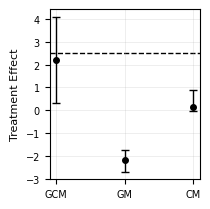

In [7]:
# Get results from first experiment, first domain
exp = experiments[0]['results_by_domain'][0]['models']
true_treatment_effect = experiments[0]['true_treatment_effect']

# Create compact plot
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

models = ['outcome_gcm', 'outcome_gm', 'outcome_cm']
model_labels_list = [MODEL_LABELS[m] for m in models]
colors = [MODEL_COLORS[m] for m in models]

for i, model_name in enumerate(models):
    if 'error' not in exp[model_name]:
        posterior_mean = exp[model_name]['posterior_mean']
        ci_5 = exp[model_name]['ci_5']
        ci_95 = exp[model_name]['ci_95']
        
        # Plot error bar
        ax.errorbar(
            i, posterior_mean,
            yerr=[[posterior_mean - ci_5], [ci_95 - posterior_mean]],
            fmt='o',
            color='k',
            capsize=3,
            capthick=1,
            markersize=4,
            elinewidth=1
        )

# Plot true treatment effect as dashed line
ax.axhline(
    true_treatment_effect,
    color='black',
    linestyle='--',
    linewidth=1,
    zorder=0
)

ax.set_xticks(range(len(models)))
ax.set_xticklabels(model_labels_list, fontsize=8)
ax.set_ylabel('Treatment Effect', fontsize=8)
ax.tick_params(labelsize=7)
ax.grid(True, alpha=0.3, linewidth=0.5)

plt.tight_layout()
if save:
    plt.savefig(os.path.join(save_folder, 'spatial_gcm_inference_example.pdf'))


## 3. Summary: Average Error Across All Experiments

Plot average error for each model across all experiments and domains.

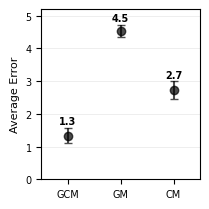

In [8]:
# Extract all errors across all experiments and domains
errors_by_model = defaultdict(list)

for exp in experiments:
    for domain_result in exp['results_by_domain']:
        for model_name, model_results in domain_result['models'].items():
            if 'error' not in model_results:
                errors_by_model[model_name].append(model_results['abs_error'])

# Compute statistics
models = ['outcome_gcm', 'outcome_gm', 'outcome_cm']
model_labels_list = [MODEL_LABELS[m] for m in models]
colors = [MODEL_COLORS[m] for m in models]

means = [np.mean(errors_by_model[m]) for m in models]
sems = [np.std(errors_by_model[m]) / np.sqrt(len(errors_by_model[m])) for m in models]

# Create compact plot
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
ax.set_ylim(0, 5.2)
ax.set_xlim(-0.5, 2.5)

x_pos = np.arange(len(models))
bars = ax.errorbar(
    x_pos,
    means,
    yerr=sems,
    color='k',
    alpha=0.7,
    capsize=3,
    capthick=1,
    linestyle='',
    marker='o'
)

# Add value labels on top of bars
for i, (mean, sem) in enumerate(zip(means, sems)):
    ax.text(
        i,
        mean + sem + 0.01 * max(means),
        f'{mean:.1f}',
        ha='center',
        va='bottom',
        fontsize=7,
        fontweight='bold'
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(model_labels_list, fontsize=8)
ax.set_ylabel('Average Error', fontsize=8)
ax.tick_params(labelsize=7)
ax.grid(True, alpha=0.3, axis='y', linewidth=0.5)

plt.tight_layout()
if save:
    plt.savefig(os.path.join(save_folder, 'spatial_gcm_avg_error.pdf'))

## 4. Summary: Coverage Across All Experiments

Plot average coverage (with standard error) for each model across all experiments and domains.

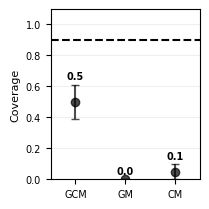

In [9]:
# Extract all coverage values across all experiments and domains
coverage_by_model = defaultdict(list)

for exp in experiments:
    for domain_result in exp['results_by_domain']:
        for model_name, model_results in domain_result['models'].items():
            if 'error' not in model_results:
                coverage_by_model[model_name].append(model_results['covers_true'])

# Compute statistics
models = ['outcome_gcm', 'outcome_gm', 'outcome_cm']
model_labels_list = [MODEL_LABELS[m] for m in models]
colors = [MODEL_COLORS[m] for m in models]

means = [np.mean(coverage_by_model[m]) for m in models]
sems = [np.std(coverage_by_model[m]) / np.sqrt(len(coverage_by_model[m])) for m in models]

# Create compact plot
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

x_pos = np.arange(len(models))
bars = ax.errorbar(
    x_pos,
    means,
    yerr=sems,
    color='k',
    alpha=0.7,
    capsize=3,
    capthick=1,
    linestyle='',
    marker='o'
)

# Add value labels on top of bars
for i, (mean, sem) in enumerate(zip(means, sems)):
    ax.text(
        i,
        mean + sem + 0.02,
        f'{mean:.1f}',
        ha='center',
        va='bottom',
        fontsize=7,
        fontweight='bold'
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(model_labels_list, fontsize=8)
ax.set_ylabel('Coverage', fontsize=8)
ax.set_ylim([0, 1.1])
ax.set_xlim([-0.5, 2.5])
plt.plot([-0.5, 2.5], [0.9, 0.9], 'k--')
ax.tick_params(labelsize=7)
ax.grid(True, alpha=0.3, axis='y', linewidth=0.5)


plt.tight_layout()
if save:
    plt.savefig(os.path.join(save_folder, 'spatial_gcm_coverage.pdf'))